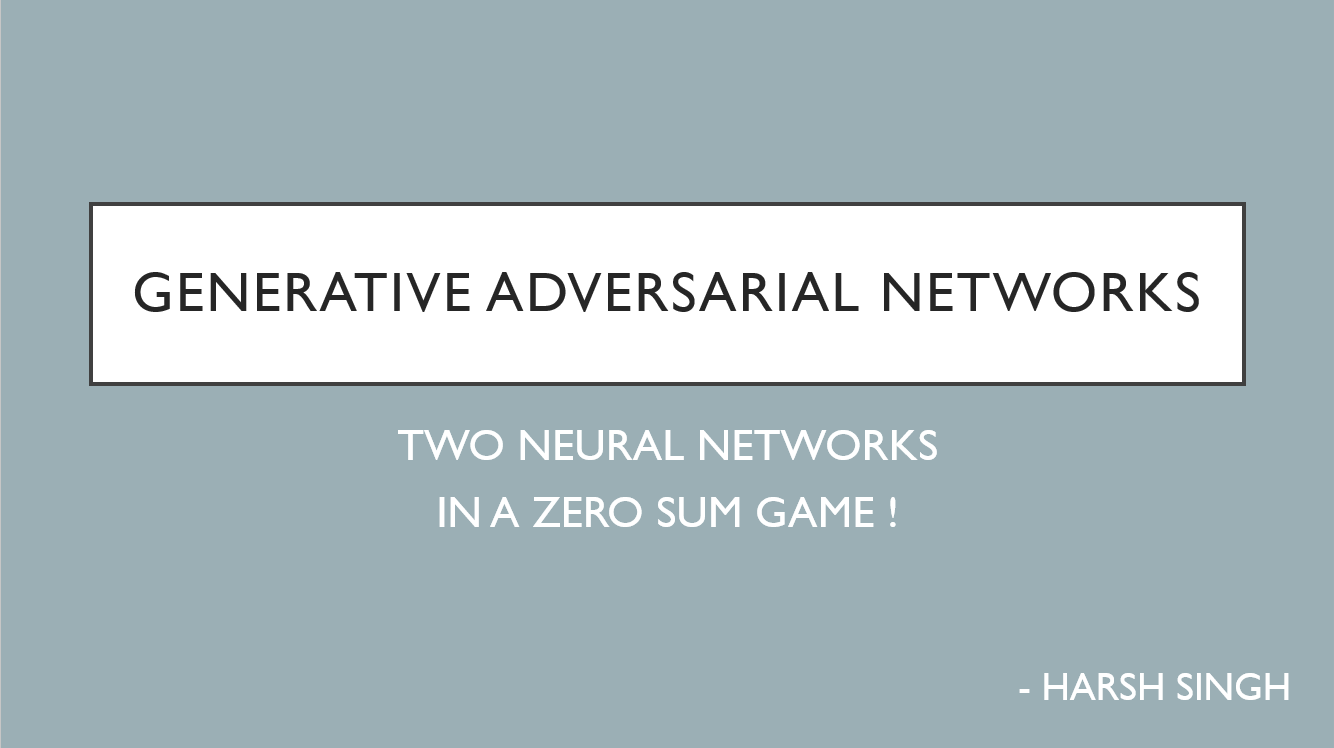

# Problem Statement

<p style="font-size:25px">Generating Brain Tumor MRI images for Data Augmentation using Generative Adversarial Networks</p>

# About Brain Tumor

<p style="font-size:20px">A brain tumor is a collection, or mass, of abnormal cells in your brain. Your skull, which encloses your brain, is very rigid. Any growth inside such a restricted space can cause problems.
Brain tumors can be cancerous (malignant) or noncancerous (benign). When benign or malignant tumors grow, they can cause the pressure inside your skull to increase. This can cause brain damage, and it can be life-threatening.
Brain tumors are categorized as primary or secondary:
<ul>
    <li style="font-size:20px">A primary brain tumor originates in your brain. Many primary brain tumors are benign.</li>
    <li style="font-size:20px">A secondary brain tumor, also known as a metastatic brain tumor, occurs when cancer cells spread to your brain from another organ, such as lung or breast. </li>
</ul>
</p>

<p align="center">
<img src="https://i0.wp.com/post.healthline.com/wp-content/uploads/2022/02/2009199_Understanding-Brain-Tumors-01.jpg?w=1155&h=1887" style="width: 725px; height: 500px"/>
</p>
<br>

# How is Brain Tumor diagnosed?
<br>
<img src="https://qph.cf2.quoracdn.net/main-qimg-3cd4287f29cd7fdc7f68ab223107bb64-pjlq" style="width:700px; height:400px">
<br>

## Magnetic Resonance Imaging (MRI)
<p>
    <ul>
        <li  style="font-size:20px">An MRI uses magnetic fields to produce detailed images of the body.<br> MRI can be used to measure the tumor’s size. A special dye called a contrast medium is given before the scan to create a clearer picture.</li> 
        <li  style="font-size:20px">This dye can be injected into a patient’s vein or given as a pill or liquid to swallow.<br> MRIs create more detailed pictures than CT scans and are the preferred way to diagnose a brain tumor.</li> 
        <li  style="font-size:20px">The MRI may be of the brain, spinal cord, or both, depending on the type of tumor suspected and the likelihood that it will spread in the CNS.</li>
        <li  style="font-size:20px">There are different types of MRI. The results of a neuro-examination, done by the internist or neurologist, helps determine which type of MRI to use.</li>
    </ul>
</p>

# What do the Numbers Say?

<ul>
    <li style="font-size:20px">In India, every year, 40,000 - 50,000 patients are diagnosed with a brain tumor. 20 percent of them are children</li>
    <li style="font-size:20px">At the current population level of the country (1.417 billion), this means only <b>0.0035 percent</b> are diagnosed with Brain Tumor!</li>
    <li style="font-size:20px">Let's assume that all MRI scans produce 100% accurate results. This would mean that for every 10,000 MRI scans, we only get <b>35 samples</b> showing Brain Tumor versus many more that don't</li>
    <li style="font-size:20px">This, combined with other problems in accessing Medical data, would lead to Machine Learning problems such as <b>Class Imbalance</b> and <b>Bias</b></li>
</ul>

<p style="font-size:15px">Source: https://health.economictimes.indiatimes.com/news/diagnostics/brain-tumors-death-on-diagnosis/88090467</p>

# A Solution - Generative Modelling

<p style="font-size:20px">Generative models, or deep generative models, are a class of deep learning models that learn the underlying data distribution from the sample. These models can be used to reduce data into its fundamental properties, or to generate new samples of data with new and varied properties</p>

# Generative Adversarial Networks

<p style="font-size:20px">Generative adversarial networks are implicit likelihood models that generate data samples from the statistical distribution of the data. They’re used to copy variations within the dataset. They use a combination of two networks: generator and discriminator.</p>
<br>
<img src="https://miro.medium.com/v2/resize:fit:720/1*9jwIuW0KPi3THIvoYg9BUQ.png" />



## <u> The Generator: </u>
<p style="font-size:20px">A generator network takes a random normal distribution (z), and outputs a generated sample that’s close to the original distribution.</p>

## <u> The Discriminator: </u>
<p style="font-size:20px">A discriminator tries to evaluate the output generated by the generator with the original sample, and outputs a value between 0 and 1. If the value is close to 0, then the generated sample is fake, and if the value is close to 1 then the generated sample is real.</p>

## <u> What the Entire thing looks like: </u>

<br><img src="https://s3.amazonaws.com/kajabi-storefronts-production/blogs/12746/images/iAOOdduQyCICwiv31aHa_dcgan.png">

## <u> How do GANs work ? </u>

<p style="font-size:20px">A random normal distribution is fed into the generator. The generator then outputs a random distribution, since it doesn’t have a reference point. <br>
Meanwhile, an actual sample, or ground truth, is fed into the discriminator. The discriminator learns the distribution of the actual sample. When the generated sample from the generator is fed into the discriminator, it evaluates the distribution.<br>
If the distribution of the generated sample is close to the original sample, then the discriminator outputs a value close to ‘1’ = real. If both the distribution doesn’t match or they aren’t even close to each other, then the discriminator outputs a value close to ‘0’ = fake.</p>

## <u> The Minimax setting </u>

<br><img src="https://static.packt-cdn.com/products/9781789139907/graphics/bf03e5ab-69ac-424d-84a7-48ea85e616ec.png" style="width:900px; height:150px;">

<p style="font-size:20px">The answer lies in the loss function or the value function; it measures the distance between the distribution of the data generated and the distribution of the real data. Both the generator and the discriminator have their own loss functions. The generator tries to minimize the loss function while the discriminator tries to maximize.</p>

# Setup

**In this project, I have used**
* Numpy and Tensorflow for Mathematical Operations
* Matplotlib and OpenCV for Image data handling and Visualization
* Keras for the Neural Networks

In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
from tqdm import tqdm
import cv2
import os
import seaborn as sns
import tensorflow as tf
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

from keras.models import Sequential, Model
from keras.layers import Dense, Flatten, Conv2D, Reshape, Input, Conv2DTranspose
from keras.layers import Activation, LeakyReLU, BatchNormalization, Dropout, Resizing
from keras.losses import BinaryCrossentropy
from tensorflow.keras.applications import VGG16

import warnings
warnings.filterwarnings('ignore')

try:
    from tensorflow.keras.optimizers import Adam
except:
    from keras.optimizers import Adam

In [2]:
NOISE_DIM = 100 
BATCH_SIZE = 16
STEPS_PER_EPOCH = 512
EPOCHS = 50
SEED = 40
WIDTH, HEIGHT, CHANNELS = 256, 256, 1

OPTIMIZER = Adam(0.0002, 0.5)

In [3]:
DATASET_PATHS = [
    "/kaggle/input/mri-brain-tumor-dataset-4-class-7023-images/BT-MRI Dataset/BT-MRI Dataset/Training/Glioma",
    "/kaggle/input/mri-brain-tumor-dataset-4-class-7023-images/BT-MRI Dataset/BT-MRI Dataset/Training/Meningioma",
    "/kaggle/input/mri-brain-tumor-dataset-4-class-7023-images/BT-MRI Dataset/BT-MRI Dataset/Training/No-tumor",
    "/kaggle/input/siardataset/Siar-dataset/Tumor",
    "/kaggle/input/siardataset/Siar-dataset/Normal",
    "/kaggle/input/brain-tumor-mri-dataset/Training/glioma",
    "/kaggle/input/brain-tumor-mri-dataset/Training/meningioma",
    "/kaggle/input/brain-tumor-mri-dataset/Training/notumor",
    "/kaggle/input/brain-tumor-classification-mri/Training/glioma_tumor",
"/kaggle/input/brain-tumor-classification-mri/Training/meningioma_tumor",
"/kaggle/input/brain-tumor-classification-mri/Training/no_tumor"

]



# Loading and Preprocessing the Images

In [4]:
def load_images(folder):
    imgs = []
    target = 1
    labels = []
    for i in os.listdir(folder):
        img_dir = os.path.join(folder,i)
        try:
            img = cv2.imread(img_dir)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            img = cv2.resize(img, (WIDTH, HEIGHT))
            imgs.append(img)
            labels.append(target)
        except:
            continue
        
    imgs = np.array(imgs)
    labels = np.array(labels)
    
    return imgs, labels

In [5]:
data = []
labels = []
for path in DATASET_PATHS:
    try:
        imgs, lbls = load_images(path)
        data.extend(imgs)
        labels.extend(lbls)
    except Exception as e:
        print(f"Error loading {path}: {e}")

data = np.array(data)
labels = np.array(labels)

## Generate 20 random numbers to index images from data

In [6]:
np.random.seed(SEED)
idxs = np.random.randint(0, 155, 20)

In [7]:
X_train = data
X_train.shape

(17552, 256, 256)

## Normalize and Reshape the Data

In [8]:
# Normalize the Images
X_train = (X_train.astype(np.float32) - 127.5) / 127.5

# Reshape images 
X_train = X_train.reshape(-1, WIDTH,HEIGHT,CHANNELS)

# Check shape
X_train.shape

(17552, 256, 256, 1)

## Plotting The Real Images

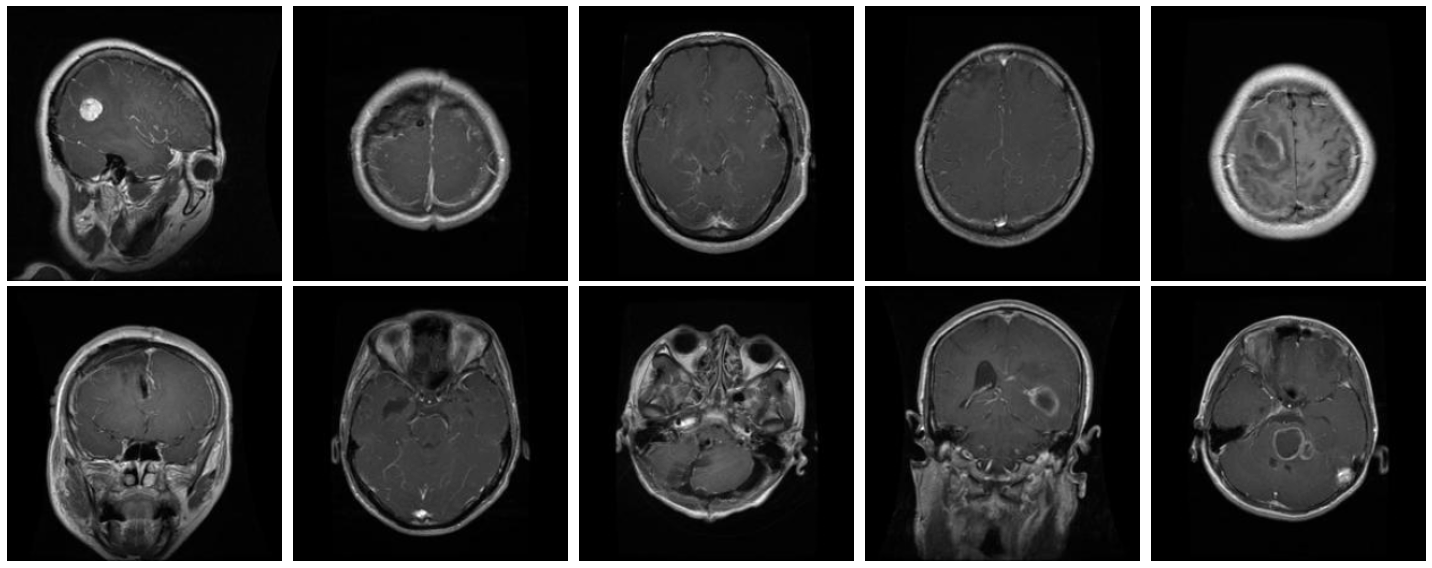

In [9]:
plt.figure(figsize=(20,8))
for i in range(10):
    axs = plt.subplot(2,5,i+1)
    plt.imshow(X_train[i], cmap="gray")
    plt.axis('off')
    axs.set_xticklabels([])
    axs.set_yticklabels([])
    plt.subplots_adjust(wspace=None, hspace=None)
plt.tight_layout()

# The Architecture

In [10]:
def build_discriminator():
    """
    Discriminator model classifies the images as real or fake
    
    Input: Image
    Output: Probability that the image is real
    """
    # The input shape must match the generator's output
    input_shape = (256, 256, 1)  # Your WIDTH, HEIGHT, CHANNELS
    
    model = Sequential([
        Conv2D(64, (4, 4), strides=2, padding='same', input_shape=input_shape),
        LeakyReLU(alpha=0.2),
        
        Conv2D(128, (4, 4), strides=2, padding='same'),
        LeakyReLU(alpha=0.2),
        
        Conv2D(256, (4, 4), strides=2, padding='same'),
        LeakyReLU(alpha=0.2),
        
        Flatten(),
        Dense(1, activation='sigmoid')
    ],
    name="discriminator")
    
    model.summary()
    model.compile(loss="binary_crossentropy", optimizer=OPTIMIZER, metrics=['accuracy'])
    
    return model

In [11]:
def build_generator():
    model = Sequential([
        Dense(16*16*256, input_dim=NOISE_DIM),  # Start with a smaller size
        LeakyReLU(alpha=0.2),
        BatchNormalization(),
        Reshape((16, 16, 256)),
        
        Conv2DTranspose(128, (4, 4), strides=2, padding='same'),  # 16 -> 32
        LeakyReLU(alpha=0.2),
        BatchNormalization(),
        
        Conv2DTranspose(64, (4, 4), strides=2, padding='same'),  # 32 -> 64
        LeakyReLU(alpha=0.2),
        BatchNormalization(),
        
        Conv2DTranspose(32, (4, 4), strides=2, padding='same'),  # 64 -> 128
        LeakyReLU(alpha=0.2),
        BatchNormalization(),
        
        Conv2DTranspose(16, (4, 4), strides=2, padding='same'),  # 128 -> 256
        LeakyReLU(alpha=0.2),
        
        Conv2D(CHANNELS, (4, 4), padding='same', activation='tanh')  # Final output layer
    ], 
    name="generator")
    
    model.summary()
    model.compile(loss="binary_crossentropy", optimizer=OPTIMIZER)  # Make sure to compile
    
    return model 

In [12]:
print('\n')
discriminator = build_discriminator()
print('\n')
generator = build_generator()

# Create the combined GAN model
discriminator.trainable = False 
gan_input = Input(shape=(NOISE_DIM,))
fake_image = generator(gan_input)
gan_output = discriminator(fake_image)
gan = Model(gan_input, gan_output, name="gan_model")
gan.compile(loss="binary_crossentropy", optimizer=OPTIMIZER)
print("The Combined Network:\n")
gan.summary()



Model: "discriminator"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d (Conv2D)              (None, 128, 128, 64)      1088      
_________________________________________________________________
leaky_re_lu (LeakyReLU)      (None, 128, 128, 64)      0         
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 64, 64, 128)       131200    
_________________________________________________________________
leaky_re_lu_1 (LeakyReLU)    (None, 64, 64, 128)       0         
_________________________________________________________________
conv2d_2 (Conv2D)            (None, 32, 32, 256)       524544    
_________________________________________________________________
leaky_re_lu_2 (LeakyReLU)    (None, 32, 32, 256)       0         
_________________________________________________________________
flatten (Flatten)            (None, 262144)        

## FID

In [13]:
from scipy import linalg
from tensorflow.keras.applications.inception_v3 import InceptionV3, preprocess_input

def calculate_fid(real_images, generated_images, batch_size=8, inception_model=None):
    """
    Calculate Fréchet Inception Distance between real and generated images
    
    Parameters:
    - real_images: numpy array of real images
    - generated_images: numpy array of generated images
    - batch_size: batch size for prediction
    - inception_model: pre-loaded inception model or None to create a new one
    
    Returns:
    - FID score (lower is better)
    """
    # Create InceptionV3 model if not provided
    if inception_model is None:
        inception_model = InceptionV3(include_top=False, pooling='avg', input_shape=(299, 299, 3))
    
    # If images are grayscale, convert to RGB by repeating the channel
    if real_images.shape[-1] == 1:
        real_images_rgb = np.repeat(real_images, 3, axis=-1)
        generated_images_rgb = np.repeat(generated_images, 3, axis=-1)
    else:
        real_images_rgb = real_images
        generated_images_rgb = generated_images
    
    # Scale images from [-1, 1] to [0, 255] for InceptionV3
    real_images_rgb = (real_images_rgb + 1) * 127.5
    generated_images_rgb = (generated_images_rgb + 1) * 127.5
    
    # Resize images to 299x299 if needed (InceptionV3's expected size)
    if WIDTH != 299 or HEIGHT != 299:
        real_resized = np.array([cv2.resize(img, (299, 299)) for img in real_images_rgb])
        gen_resized = np.array([cv2.resize(img, (299, 299)) for img in generated_images_rgb])
    else:
        real_resized = real_images_rgb
        gen_resized = generated_images_rgb
    
    # Preprocess images for Inception
    real_resized = preprocess_input(real_resized)
    gen_resized = preprocess_input(gen_resized)
    
    # Extract features
    real_features = inception_model.predict(real_resized, batch_size=batch_size)
    gen_features = inception_model.predict(gen_resized, batch_size=batch_size)
    
    # Calculate mean and covariance statistics
    mu_real = np.mean(real_features, axis=0)
    sigma_real = np.cov(real_features, rowvar=False)
    
    mu_gen = np.mean(gen_features, axis=0)
    sigma_gen = np.cov(gen_features, rowvar=False)
    
    # Calculate FID
    ssdiff = np.sum((mu_real - mu_gen) ** 2.0)
    covmean = linalg.sqrtm(sigma_real.dot(sigma_gen))
    
    # Check if covmean has complex components
    if np.iscomplexobj(covmean):
        covmean = covmean.real
        
    fid = ssdiff + np.trace(sigma_real + sigma_gen - 2.0 * covmean)
    
    return fid

# Load the InceptionV3 model once before training
print("Loading InceptionV3 model for FID calculation...")
inception_model = InceptionV3(include_top=False, pooling='avg', input_shape=(299, 299, 3))

# Modified training loop with FID calculation
def train_gan_with_fid(generator, discriminator, gan, X_train, epochs=10, batch_size=8, 
                       steps_per_epoch=1024, noise_dim=100, save_interval=1):
    # Create lists to store metrics for plotting
    d_losses = []
    g_losses = []
    fid_scores = []
    
    # Start training
    for epoch in range(epochs):
        epoch_d_losses = []
        epoch_g_losses = []
        
        for batch in tqdm(range(steps_per_epoch)):
            # Generate random noise
            noise = np.random.normal(0, 1, size=(batch_size, noise_dim))
            fake_X = generator.predict(noise)
            
            # Get real samples
            idx = np.random.randint(0, X_train.shape[0], size=batch_size)
            real_X = X_train[idx]
            
            # Combine real and fake samples
            X = np.concatenate((real_X, fake_X))
            
            # Create labels
            disc_y = np.zeros(2*batch_size)
            disc_y[:batch_size] = 0.9  # Label smoothing for real samples
            
            # Train discriminator
            d_loss = discriminator.train_on_batch(X, disc_y)
            epoch_d_losses.append(d_loss[0])
            
            # Train generator
            noise = np.random.normal(0, 1, size=(batch_size, noise_dim))
            y_gen = np.ones(batch_size)  # We want discriminator to think these are real
            
            # Make discriminator untrainable for generator update
            discriminator.trainable = False
            g_loss = gan.train_on_batch(noise, y_gen)
            epoch_g_losses.append(g_loss)
            
            # Make discriminator trainable again
            discriminator.trainable = True
        
        # Average losses for this epoch
        avg_d_loss = np.mean(epoch_d_losses)
        avg_g_loss = np.mean(epoch_g_losses)
        d_losses.append(avg_d_loss)
        g_losses.append(avg_g_loss)
        
        # Calculate FID score
        if epoch % save_interval == 0:
            # Use a subset of real images
            real_subset = X_train[:100]
            
            # Generate images for FID
            noise_fid = np.random.normal(0, 1, size=(100, noise_dim))
            gen_subset = generator.predict(noise_fid)
            
            # Calculate FID
            fid = calculate_fid(real_subset, gen_subset, batch_size=batch_size, inception_model=inception_model)
            fid_scores.append(fid)
            
            print(f"EPOCH: {epoch + 1}/{epochs} | Generator Loss: {avg_g_loss:.4f} | Discriminator Loss: {avg_d_loss:.4f} | FID: {fid:.4f}")
            
            # Sample and visualize generated images
            noise = np.random.normal(0, 1, size=(10, noise_dim))
            sample_images(noise, (2, 5))
        else:
            print(f"EPOCH: {epoch + 1}/{epochs} | Generator Loss: {avg_g_loss:.4f} | Discriminator Loss: {avg_d_loss:.4f}")
    
    # Plot metrics
    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(range(1, epochs + 1), d_losses, label='Discriminator Loss')
    plt.plot(range(1, epochs + 1), g_losses, label='Generator Loss')
    plt.title('Training Losses')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(range(1, epochs + 1, save_interval), fid_scores, marker='o', linestyle='-')
    plt.title('FID Score per Epoch')
    plt.xlabel('Epoch')
    plt.ylabel('FID Score (lower is better)')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('gan_training_metrics.png')
    plt.show()
    
    return d_losses, g_losses, fid_scores

# Final evaluation function
def evaluate_model_fid(generator, X_train, n_samples=1000, noise_dim=100):
    """
    Evaluate the generator model using FID
    
    Parameters:
    - generator: trained generator model
    - X_train: real images dataset
    - n_samples: number of samples to generate
    
    Returns:
    - FID score
    """
    # Use a subset of real images
    if n_samples > len(X_train):
        n_samples = len(X_train)
    
    real_subset = X_train[:n_samples]
    
    # Generate images
    noise = np.random.normal(0, 1, size=(n_samples, noise_dim))
    generated_images = generator.predict(noise)
    
    # Calculate FID
    inception_model = InceptionV3(include_top=False, pooling='avg', input_shape=(299, 299, 3))
    fid = calculate_fid(real_subset, generated_images, inception_model=inception_model)
    
    print(f"Final FID Score: {fid:.4f}")
    return fid

Loading InceptionV3 model for FID calculation...
87924736/87910968 [==============================] - 0s 0us/step


# Putting it together

In [14]:
def sample_images(noise, subplots, figsize=(22,8), save=False):
    generated_images = generator.predict(noise)

    # Create output folder if it doesn't exist
    output_folder = "/kaggle/working/generated_outputs"
    os.makedirs(output_folder, exist_ok=True)

    plt.figure(figsize=figsize)
    for i, image in enumerate(generated_images):
        plt.subplot(subplots[0], subplots[1], i+1)
        if CHANNELS == 1:
            plt.imshow(image.reshape((WIDTH, HEIGHT)), cmap='gray')
        else:
            plt.imshow(image.reshape((WIDTH, HEIGHT, CHANNELS)))
        if save:
            img_path = os.path.join(output_folder, f"gen_{i}.png")
            plt.imsave(img_path, image.reshape((WIDTH, HEIGHT)), cmap='gray')
        plt.axis('off')

    plt.tight_layout()
    plt.show()

## Z Space Interpolation

In [15]:
def visualize_z_space_interpolation(num_pairs=5, steps_per_pair=10):
    """
    Visualize interpolation between random points in the latent space.
    
    Parameters:
    - num_pairs: Number of random pairs to interpolate between
    - steps_per_pair: Number of interpolation steps for each pair
    """
    plt.figure(figsize=(15, num_pairs * 2))
    
    # Generate random pairs of latent vectors
    for pair in range(num_pairs):
        # Generate two random points in latent space
        z1 = np.random.normal(0, 1, size=(1, NOISE_DIM))
        z2 = np.random.normal(0, 1, size=(1, NOISE_DIM))
        
        # Create interpolated points between z1 and z2
        alphas = np.linspace(0, 1, steps_per_pair)
        z_interpolations = np.zeros((steps_per_pair, NOISE_DIM))
        
        # Linear interpolation between z1 and z2
        for i, alpha in enumerate(alphas):
            z_interpolations[i] = alpha * z2[0] + (1 - alpha) * z1[0]
        
        # Generate images from interpolated points
        interpolated_images = generator.predict(z_interpolations)
        
        # Display interpolated images for this pair
        for i in range(steps_per_pair):
            plt.subplot(num_pairs, steps_per_pair, pair * steps_per_pair + i + 1)
            
            if CHANNELS == 1:
                plt.imshow(interpolated_images[i].reshape(WIDTH, HEIGHT), cmap='gray')
            else:
                plt.imshow(interpolated_images[i].reshape(WIDTH, HEIGHT, CHANNELS))
                
            plt.axis('off')
    
    plt.tight_layout()
    plt.show()
# Load the InceptionV3 model once before training
inception_model = InceptionV3(include_top=False, pooling='avg', input_shape=(299, 299, 3))


## The Training

In [16]:
fid_scores = []
d_losses = []
g_losses = []
d_accuracies = []

np.random.seed(SEED)
for epoch in range(EPOCHS):
    epoch_d_losses = []
    epoch_d_accs = []
    epoch_g_losses = []
    
    for batch in tqdm(range(STEPS_PER_EPOCH)):
        # Generate fake images
        noise = np.random.normal(0, 1, size=(BATCH_SIZE, NOISE_DIM))
        fake_X = generator.predict(noise)
        
        # Get real images
        idx = np.random.randint(0, X_train.shape[0], size=BATCH_SIZE)
        real_X = X_train[idx]
        
        # Combine real and fake images
        X = np.concatenate((real_X, fake_X))
        
        # Labels for discriminator (1 for real, 0 for fake)
        disc_y = np.zeros(2*BATCH_SIZE)
        disc_y[:BATCH_SIZE] = 1
        
        # Train discriminator
        d_metrics = discriminator.train_on_batch(X, disc_y)
        # d_metrics is a list where d_metrics[0] is loss and d_metrics[1] is accuracy
        epoch_d_losses.append(d_metrics[0])
        epoch_d_accs.append(d_metrics[1])
        
        # Train generator
        noise = np.random.normal(0, 1, size=(BATCH_SIZE, NOISE_DIM))
        y_gen = np.ones(BATCH_SIZE)  # We want the discriminator to classify fake images as real
        g_loss = gan.train_on_batch(noise, y_gen)
        epoch_g_losses.append(g_loss)
    
    # Calculate average metrics for this epoch
    avg_d_loss = np.mean(epoch_d_losses)
    avg_d_acc = np.mean(epoch_d_accs)
    avg_g_loss = np.mean(epoch_g_losses)
    
    # Save metrics for plotting
    d_losses.append(avg_d_loss)
    d_accuracies.append(avg_d_acc)
    g_losses.append(avg_g_loss)
    
    # Calculate FID at the end of each epoch
    # Take a subset of real images for FID calculation to speed it up
    real_subset = X_train[:100]  # Adjust size based on your memory constraints
    
    # Generate images for FID calculation
    noise_fid = np.random.normal(0, 1, size=(100, NOISE_DIM))
    gen_subset = generator.predict(noise_fid)
    
    # Calculate FID
    fid = calculate_fid(real_subset, gen_subset, batch_size=BATCH_SIZE, inception_model=inception_model)
    fid_scores.append(fid)
    
    print(f"EPOCH: {epoch + 1} Gen Loss: {avg_g_loss:.4f} Disc Loss: {avg_d_loss:.4f} Disc Acc: {avg_d_acc:.2f} FID: {fid:.4f}")
    

100%|██████████| 512/512 [01:29<00:00,  5.70it/s]


EPOCH: 1 Gen Loss: 0.5994 Disc Loss: 0.4831 Disc Acc: 0.95 FID: 357.2444


100%|██████████| 512/512 [01:20<00:00,  6.36it/s]


EPOCH: 2 Gen Loss: 0.8600 Disc Loss: 0.5969 Disc Acc: 0.72 FID: 346.1010


100%|██████████| 512/512 [01:20<00:00,  6.35it/s]


...

EPOCH: 48 Gen Loss: 1.9524 Disc Loss: 0.5329 Disc Acc: 0.81 FID: 162.8721


100%|██████████| 512/512 [01:20<00:00,  6.33it/s]


EPOCH: 49 Gen Loss: 1.8574 Disc Loss: 0.3475 Disc Acc: 0.85 FID: 155.5338


100%|██████████| 512/512 [01:20<00:00,  6.38it/s]


EPOCH: 50 Gen Loss: 1.9676 Disc Loss: 0.3584 Disc Acc: 0.84 FID: 157.7596


# Let's generate some images !

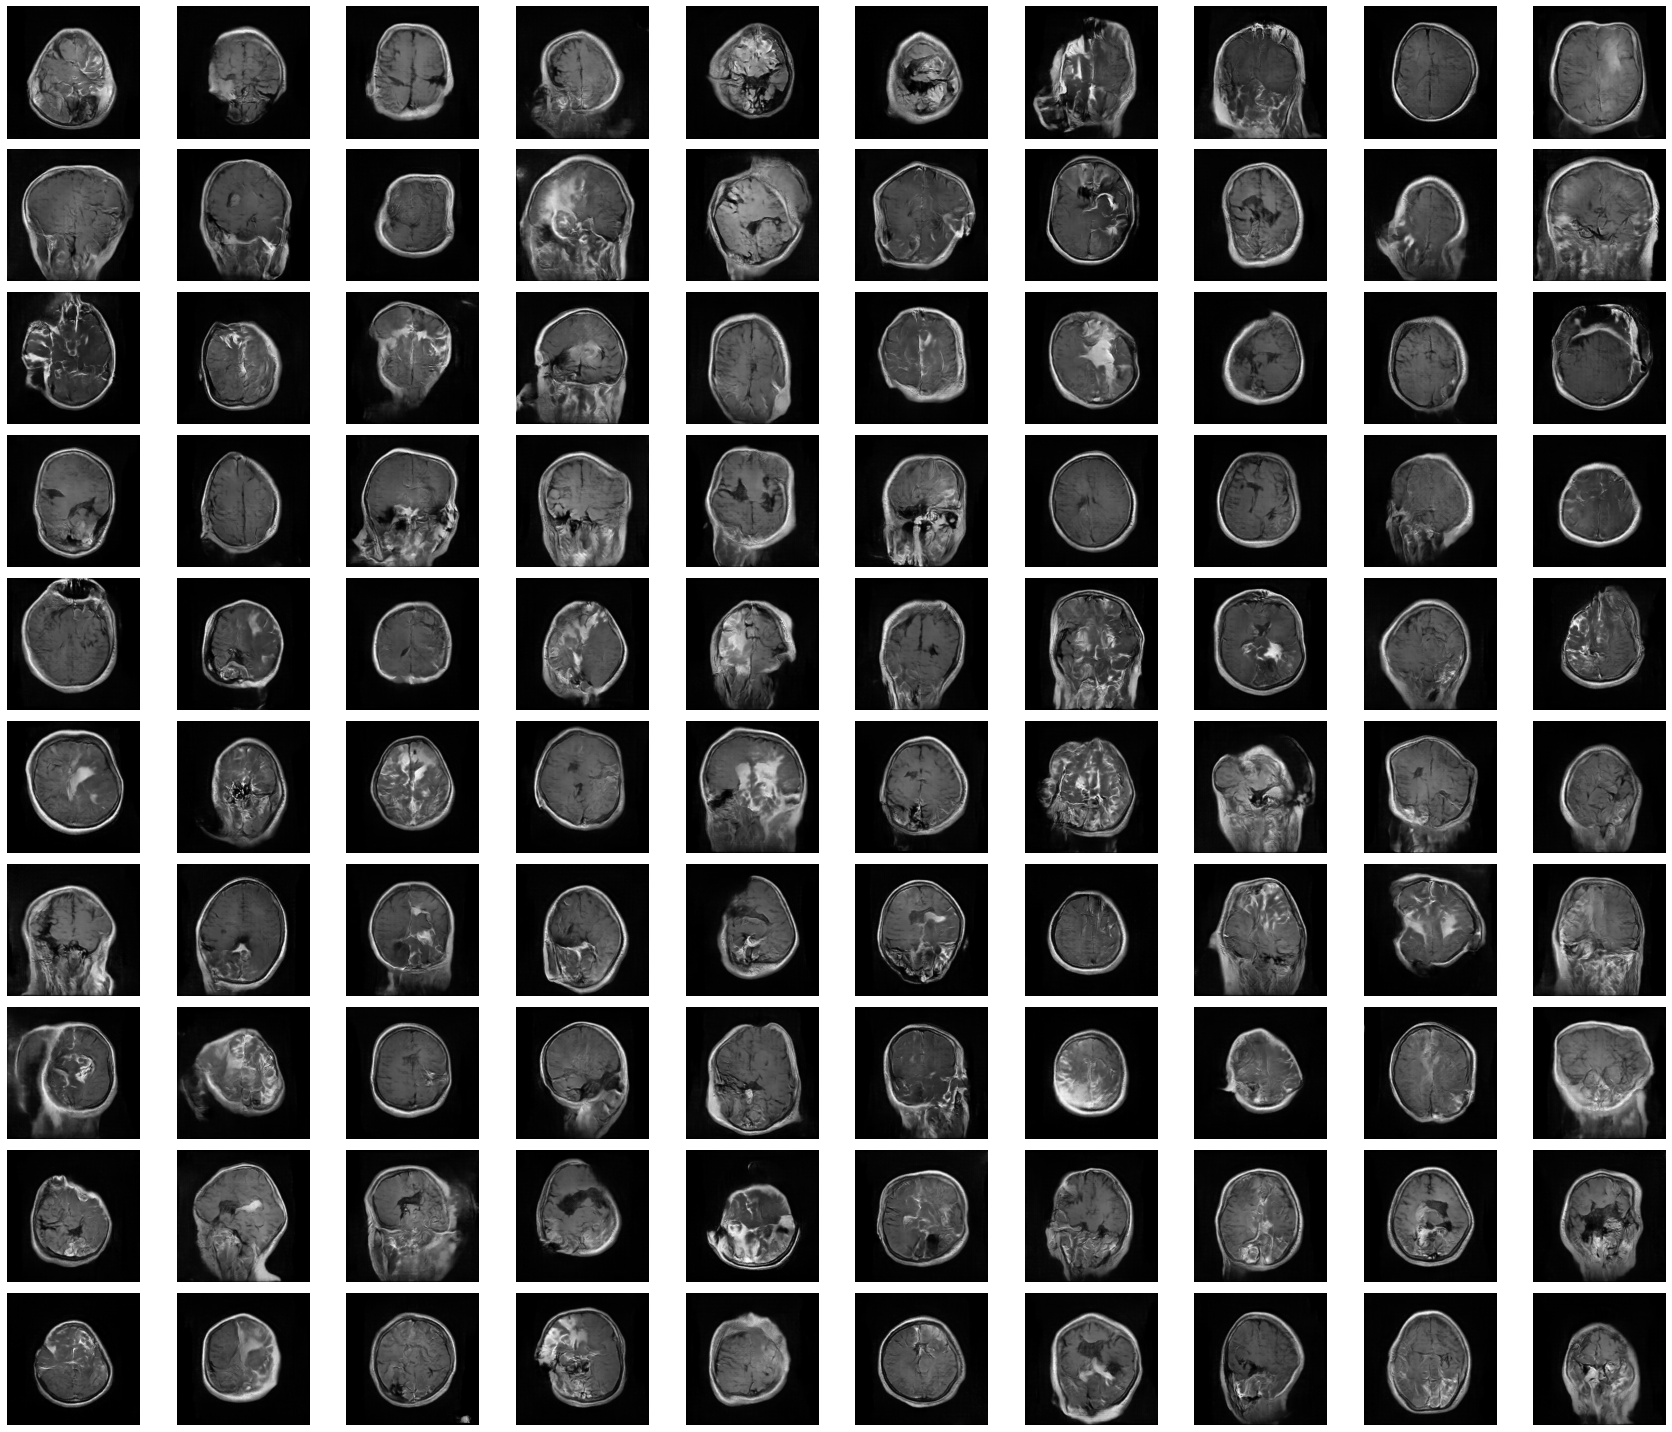

In [17]:
noise = np.random.normal(0, 1, size=(100, NOISE_DIM))
sample_images(noise, (10,10), (24,20), save=True)

# Testing the Generated sample: Plotting the Distributions

<p style="font-size:20px">In this test, we compare the generated images with the real samples by plotting their distributions. If the distributions overlap, that indicates the generated samples are very close to the real ones
</p>

In [18]:
generated_images = generator.predict(noise)

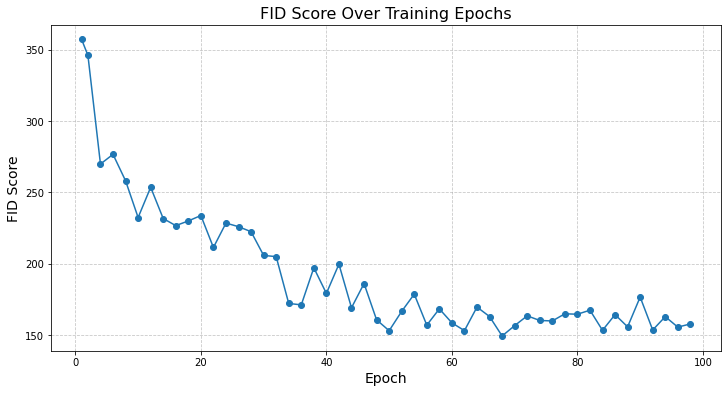

Final Z-Space Interpolation Visualization:


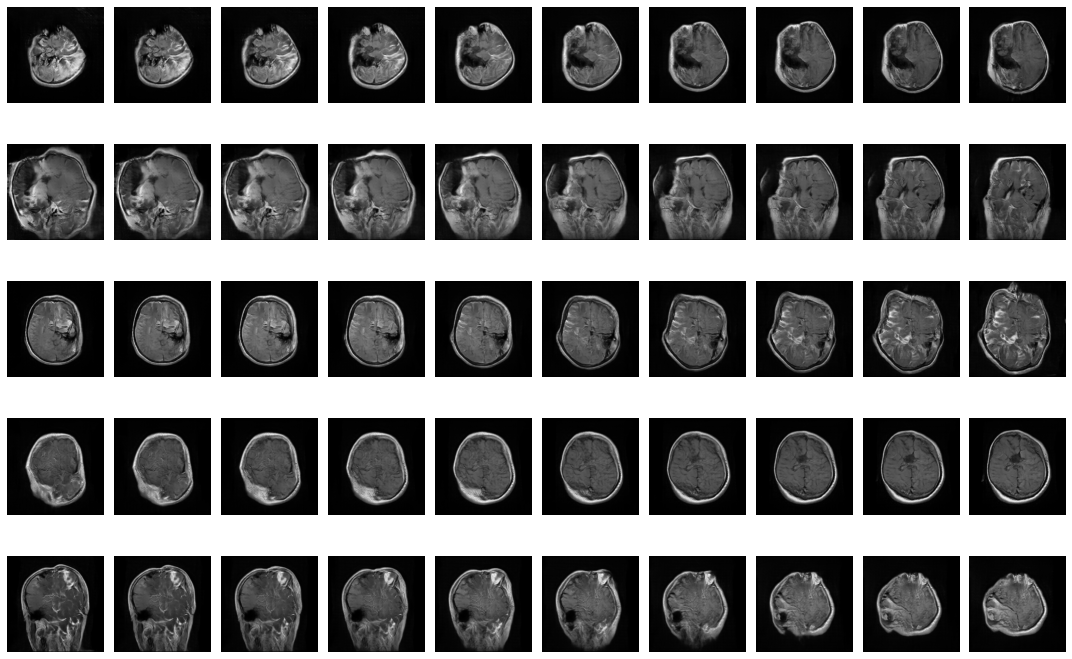

Final FID Score: 101.2937


(100, 256, 256, 1)

In [19]:
plt.figure(figsize=(12, 6))
plt.plot([i*2 if i > 0 else 1 for i in range(len(fid_scores))], fid_scores, marker='o')
plt.title('FID Score Over Training Epochs', fontsize=16)
plt.xlabel('Epoch', fontsize=14)
plt.ylabel('FID Score', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Visualize final z-space interpolations with more detail
print("Final Z-Space Interpolation Visualization:")
visualize_z_space_interpolation(num_pairs=5, steps_per_pair=10)
def evaluate_model_fid(generator, X_train, n_samples=1000):
    """
    Evaluate the generator model using FID
    
    Parameters:
    - generator: trained generator model
    - X_train: real images dataset
    - n_samples: number of samples to generate
    
    Returns:
    - FID score
    """
    # Use a subset of real images
    if n_samples > len(X_train):
        n_samples = len(X_train)
    
    real_subset = X_train[:n_samples]
    
    # Generate images
    noise = np.random.normal(0, 1, size=(n_samples, NOISE_DIM))
    generated_images = generator.predict(noise)
    
    # Calculate FID
    fid = calculate_fid(real_subset, generated_images)
    
    print(f"Final FID Score: {fid:.4f}")
    return fid

# Call this after training
final_fid = evaluate_model_fid(generator, X_train)
generated_images = generator.predict(noise)
generated_images.shape

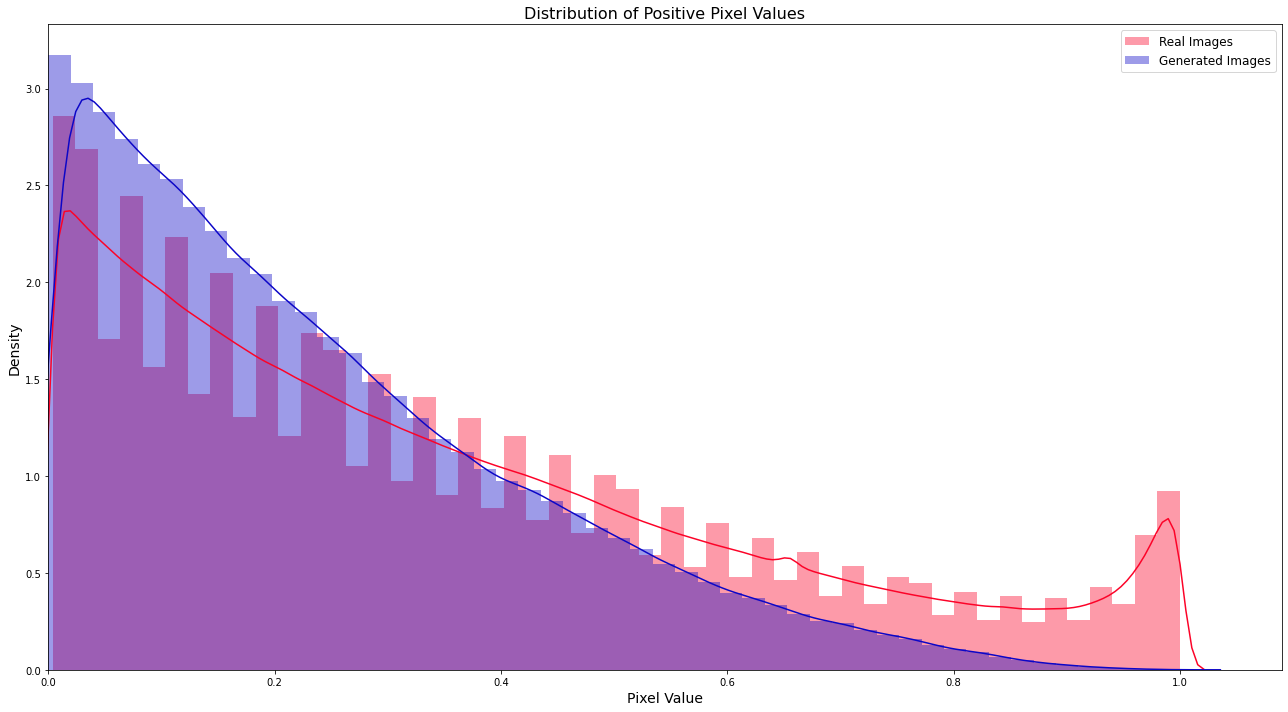

In [20]:
# First reshape the data to 1D arrays
X_train_flat = X_train.flatten()
generated_images_flat = generated_images.flatten()

# Only keep positive values (values >= 0)
X_train_positive = X_train_flat[X_train_flat >= 0]
generated_images_positive = generated_images_flat[generated_images_flat >= 0]

# Create the plot
fig, axs = plt.subplots(ncols=1, nrows=1, figsize=(18,10))

# Plot distributions using only positive values
sns.distplot(X_train_positive, label='Real Images', hist=True, color='#fc0328', ax=axs)
sns.distplot(generated_images_positive, label='Generated Images', hist=True, color='#0c06c7', ax=axs)

# Add legend and labels
axs.legend(loc='upper right', prop={'size': 12})
axs.set_title('Distribution of Positive Pixel Values', fontsize=16)
axs.set_xlabel('Pixel Value', fontsize=14)
axs.set_ylabel('Density', fontsize=14)

# Set x-axis to start at 0
axs.set_xlim(left=0)

plt.tight_layout()
plt.show()

# Some other testing methods

<p style="font-size:20px">
<ul>
    <li style="font-size:20px">Average Log-likelihood</li>
    <li style="font-size:20px">Inception Score</li>
    <li style="font-size:20px">Wasserstien Metric</li>
</ul>
</p>

# Conclusion

<p style="font-size:20px">
    As we can see from the plot, the distribution of Generated Images is approximately the same as that of the Real Images. From this we can conclude that the generated images are a true representative of the real ones, capturing most of the variations.
</p>

# References

<p style="font-size:20px">
<ul>
    <li style="font-size:20px"><a href="https://arxiv.org/abs/1406.2661">Generative Adversarial Networks</a> (2014)</li>
    <li style="font-size:20px"><a href="https://arxiv.org/abs/1606.03498">Improved Techniques for Training GANs</a> (2016)</li>
    <li style="font-size:20px"><a href="https://arxiv.org/abs/2108.03235">SMOTified-GAN for class imbalanced pattern classification problems</a> (2021)</li>
</ul>
</p>

In [21]:
![image.png](attachment:cd4bfd85-9bf6-45b7-b781-72321230eee7.png)

/bin/bash: -c: line 0: syntax error near unexpected token `attachment:cd4bfd85-9bf6-45b7-b781-72321230eee7.png'
/bin/bash: -c: line 0: `[image.png](attachment:cd4bfd85-9bf6-45b7-b781-72321230eee7.png)'
